In [2]:
import medmnist
from medmnist import INFO, DermaMNIST

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
info = INFO["dermamnist"]

print(info)

{'python_class': 'DermaMNIST', 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.', 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1', 'MD5': '0744692d530f8e62ec473284d019b0c7', 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1', 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f', 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1', 'MD5_128': '2defd784463fa5243564e855ed717de1', 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1', 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d', 'task': 'multi-class', 'la

In [13]:
for key, value in info['label'].items():
    print(f"{key}: {value}")

0: actinic keratoses and intraepithelial carcinoma
1: basal cell carcinoma
2: benign keratosis-like lesions
3: dermatofibroma
4: melanoma
5: melanocytic nevi
6: vascular lesions


In [6]:
train_dataset = DermaMNIST(split="train", download=True)

print("Number of training images:", len(train_dataset))

Using downloaded and verified file: /Users/mohosina/.medmnist/dermamnist.npz
Number of training images: 7007


In [7]:
image, label = train_dataset[0]

print(type(image))
print(image.size)
print(label)

<class 'PIL.Image.Image'>
(28, 28)
[0]


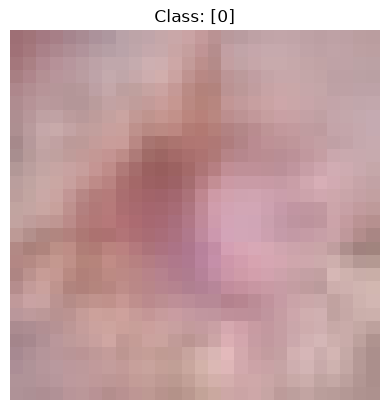

In [8]:
plt.imshow(image)
plt.title(f"Class: {label}")
plt.axis("off")
plt.show()

## 1. Visualize random sample

In [10]:
label_map = info['label']

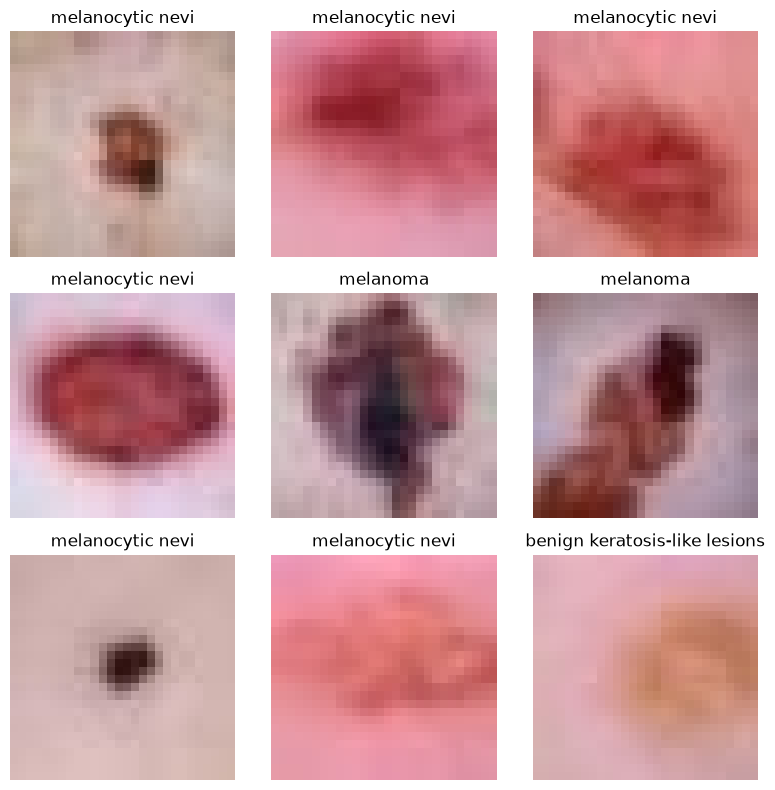

In [11]:
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(3,3, figsize=(8,8))

for ax in axes.ravel():

    idx = random.randint(0, len(train_dataset)-1)

    image, label = train_dataset[idx]

    ax.imshow(image)

    ax.set_title(label_map[str(label[0])])

    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. Class Distribution Analysis

In [14]:
from collections import Counter

labels = []

for _, label in train_dataset:
    labels.append(int(label))

counts = Counter(labels)

print(counts)

Counter({5: 4693, 4: 779, 2: 769, 1: 359, 0: 228, 6: 99, 3: 80})


/var/folders/pb/tfl2qv_n2yldkyqw5x6rllgh0000gn/T/ipykernel_5919/1510005226.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels.append(int(label))


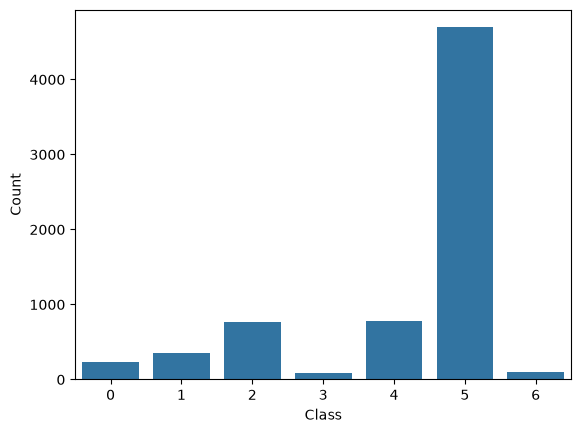

In [15]:
import seaborn as sns
import pandas as pd

df = pd.DataFrame(
    counts.items(),
    columns=["Class","Count"]
)

sns.barplot(
    x="Class",
    y="Count",
    data=df
)

plt.show()

## 3. Convert Labels to Names

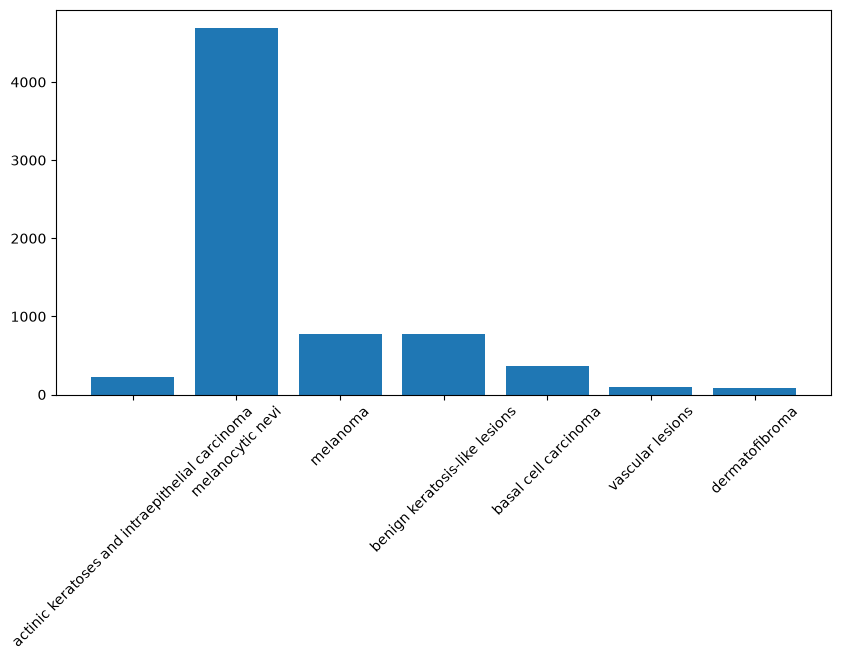

In [16]:
class_names = [
    label_map[str(c)]
    for c in counts.keys()
]

plt.figure(figsize=(10,5))

plt.bar(class_names, counts.values())

plt.xticks(rotation=45)

plt.show()

## 4. Pixel Intensity Distribution

In [17]:
import numpy as np

pixels = []

for image, _ in train_dataset:

    image = np.array(image)

    pixels.extend(image.flatten())

pixels = np.array(pixels)

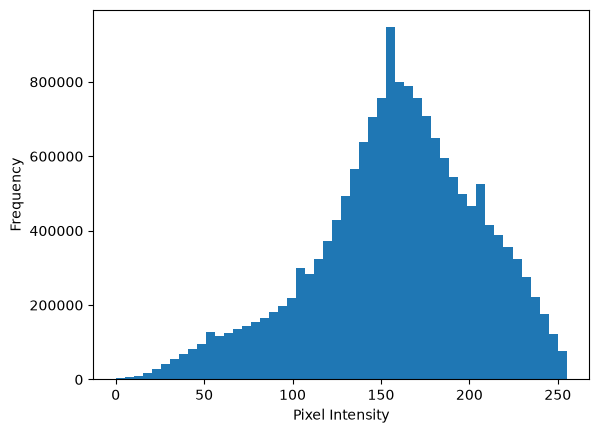

In [18]:
plt.hist(
    pixels,
    bins=50
)

plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

## 5. RGB Channel Analysis

In [21]:
reds = []
greens = []
blues = []

for image, _ in train_dataset:

    img = np.array(image)

    reds.append(img[:,:,0].mean())
    greens.append(img[:,:,1].mean())
    blues.append(img[:,:,2].mean())

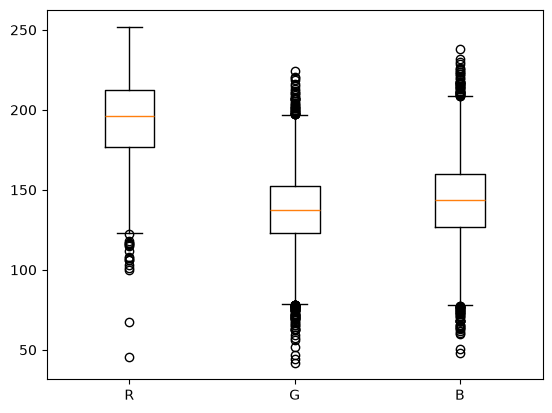

In [23]:
plt.boxplot([reds, greens, blues])

plt.xticks([1, 2, 3], ["R", "G", "B"])

plt.show()

## 6. Average image per class

In [25]:
class_images = {}

for c in range(7):

    imgs = []

    for image, label in train_dataset:

        if label[0] == c:
            imgs.append(np.array(image))

    class_images[c] = np.mean(imgs, axis=0)


In [26]:
image, label = train_dataset[0]

print(label)
print(type(label))
print(label.shape)

[0]
<class 'numpy.ndarray'>
(1,)


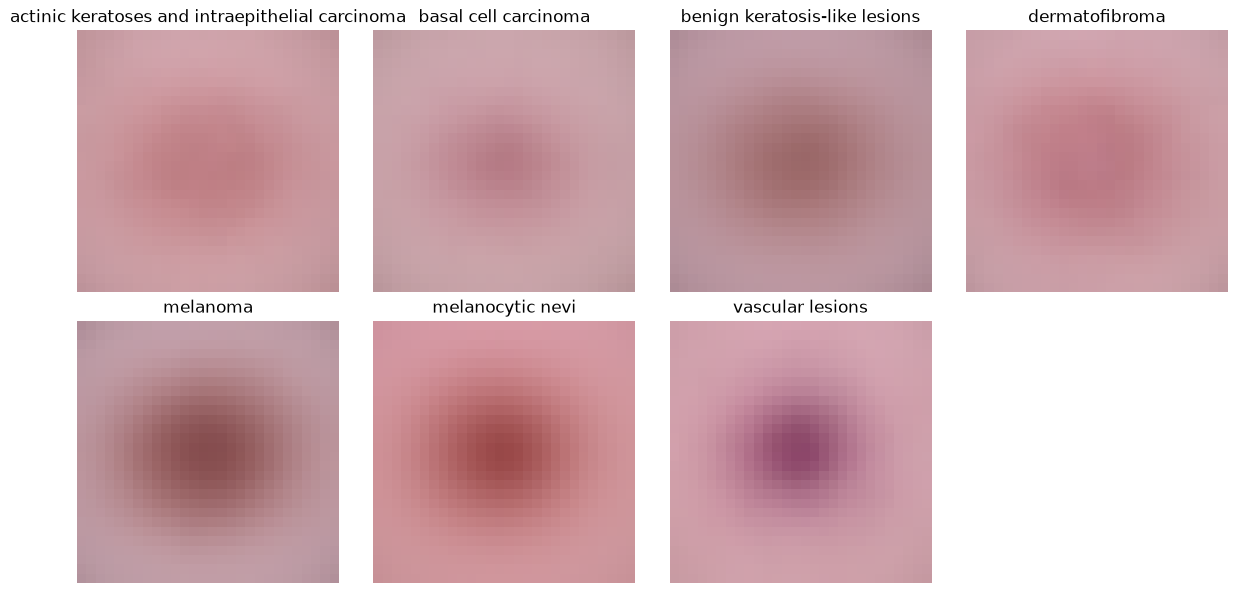

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for c in range(7):

    ax = axes.ravel()[c]

    ax.imshow(class_images[c].astype(np.uint8))

    ax.set_title(label_map[str(c)])

    ax.axis("off")

# Remove unused subplot
axes.ravel()[7].axis("off")

plt.tight_layout()
plt.show()

## 7. Image Dimension Verification

In [28]:
sizes = []

for image, _ in train_dataset:

    sizes.append(image.size)

print(set(sizes))

{(28, 28)}


## 8. Detect Potential Outliers

In [29]:
brightness = []

for image, _ in train_dataset:

    img = np.array(image)

    brightness.append(img.mean())

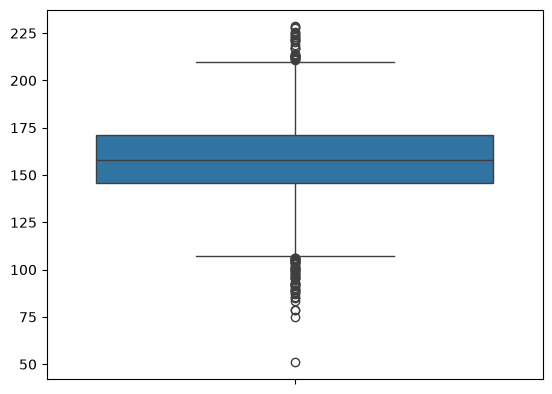

In [30]:
sns.boxplot(brightness)

plt.show()